This notebook tests basic simulation by recapitulating a simulated dataset several times and measuring variance.

Imports

In [2]:
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import scMPRAforge as scm
import pandas as pd
import numpy as np

In [2]:
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

In [3]:
#dask imports
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
import socket

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

Make the dask cluster & client in accordance with resource avail and model size

In [ ]:
cluster=LocalCluster()
#cluster=SLURMCluster(
#    cores=2,#cores per slurm job
#    memory="16G",#memory per slurm job
#    processes=1,#dask workers per slurm job
#    job_extra_directives=["-p ycga", 
#        f"--job-name=simclust_worker",
#        f"--time=2:00:00",
#        f"--output=slave_%j.out"]
#)
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

2025-06-11 12:08:19,399 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 20bf8920a93e88863c6fa34051ce0813 initialized by task ('shuffle-transfer-20bf8920a93e88863c6fa34051ce0813', 1) executed on worker tcp://127.0.0.1:52065
2025-06-11 12:08:19,418 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 50cd4d0d49d63728a3d89b266af9ccd5 initialized by task ('shuffle-transfer-50cd4d0d49d63728a3d89b266af9ccd5', 1) executed on worker tcp://127.0.0.1:52065
2025-06-11 12:08:19,730 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 20bf8920a93e88863c6fa34051ce0813 deactivated due to stimulus 'task-finished-1749658099.729364'
2025-06-11 12:08:19,733 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 50cd4d0d49d63728a3d89b266af9ccd5 deactivated due to stimulus 'task-finished-1749658099.7324429'
2025-06-11 12:08:20,020 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d84490d49d12fd95db0ef9ca791d1779 initialized by task ('shuffle-transfer-d84490d49d12fd9

In [23]:
class simulation_batch:
    """
    Class which takes a single <ortho> object and simulates replicates.
    Optionally, fits additional ortho objects to simulations
    Useful for estimating variance of an experimental setup...
    """
    #several functions modify state in a way necessary for subsq functions: add checks to make sure prev. has been called.
    
    #consolidate split and parameter validity checking

    splits=["cre_id","cell_type"]

    def __init__(self,primordial,partition_mb=50):
        #the initial 
        self.primordial=primordial
        
        self.simulated_from_cre=[]
        self.simulated_from_cell_type=[]

        self.ortho_simulated_cre=[]
        self.ortho_simulated_cell_type=[]

        self.partition_mb=partition_mb
    
    def describe_primordial(self,client,dat):
        """Generates and saves descriptions of the primordial which are necessary for subsequent simulation"""
        self.description_primordial_by_cre=scm.describe_parameters(client,
                                                                   parameters=self.primordial.by_cre_parameters.result(),
                                                                   dat=dat,
                                                                   split="cre_id")

        self.description_primordial_by_cre=scm.auto_partition(self.description_primordial_by_cre,
                                                              self.partition_mb)

        self.description_primordial_by_cell_type=scm.describe_parameters(client,
                                                                         parameters=self.primordial.by_cell_type_parameters.result(),
                                                                         dat=dat,
                                                                         split="cell_type")
        
        self.description_primordial_by_cell_type=scm.auto_partition(self.description_primordial_by_cell_type,
                                                                    self.partition_mb)

    def clear_simulations(self):
        """Removes simulated data. Does not remove models fit to simulated data. Useful for reducing object size"""
        pass
        #del self.simulations
        #self.simulations=[]
    
    def _round_of_simu(self,client,description_primordial):
        """
        Simulates one replicate from a given description. 
        """
        #s for simulated
        s=scm.simulate_from_description(description_primordial).compute()
        s=scm.undo_one_hot_encoding(s)
        s=s.rename({'zinb_sample':'umis_mpra_bc'},axis=1)[['rep_id','cre_id','cell_type','umis_mpra_bc']]
        return s
    
    def simulate_many(self,client,n):
        """
        simulates n replicates
        Depends on 
        """
        #add parallel scatter-gather here!
        for _ in range(0,n):
            self.simulated_from_cre.append(self._round_of_simu(client,self.description_primordial_by_cre))
            self.simulated_from_cell_type.append(self._round_of_simu(client,self.description_primordial_by_cell_type))

    def fit_to_simulations(self,client):
        """
        Fits ortho models to all simulated datasets.
        Depends on simulate_many having been called. 
        """
        
        #add parallel scatter-gather here!

        #from cre
        for s in self.simulated_from_cre:
            recap=scm.ortho()
            recap.criss_cross(client=client,dat=s)
            recap.extract_params(client)
            self.ortho_simulated_cre.append(recap)

        #from cell
        for s in self.simulated_from_cell_type:
            recap=scm.ortho()
            recap.criss_cross(client=client,dat=s)
            recap.extract_params(client)
            self.ortho_simulated_cell_type.append(recap)
    
    def _flatten_all_parameters(self):
        """Flatten all parameters in preparation for plotting"""
        #old from_cre and from_cell_type are the orthos...

        splits=["cre_id","cell_type"]
        vars=["nb","zi","theta"]

        nbs=[]
        zi_cre=[]
        zi_cell=[]

        theta_cre=[]
        theta_cell=[]

        def flatten_results(working,split:str,var:str):
            """Internal, temporary function"""
            if split not in splits or var not in vars:
                raise ValueError("invalid chocie")
            #add check for valid working split var
            
            if var=="theta":
                if split=="cre_id":
                    working=working.by_cre_parameters.result()
                elif split=="cell_type":
                    working=working.by_cell_type_parameters.result()
                
                working=pd.DataFrame([working.theta]).T
                working=working.reset_index()
                working.columns=[split,"theta"]
                working['theta']=working['theta'].astype(float)
                return working

            if split=="cre_id":
                working=working.by_cre_parameters.result()
            elif split=="cell_type":
                working=working.by_cell_type_parameters.result()
            if var =="nb":
                working=pd.concat(working.nb)
            elif var =="zi":
                working=pd.concat(working.zi)
            working.index=working.index.set_names(split,level=0)
            working=working.reset_index()
            working=scm.undo_one_hot_encoding(working)
            return working

        #add primordial for reference
        for split in splits:
            for var in ["nb","zi","theta"]:
                #nb
                prim_flattened=flatten_results(self.primordial,split,var)
                prim_flattened["id"]=f"primordial {split}"
                prim_flattened["rep"]="primordial"
                if var=="nb":
                    nbs.append(prim_flattened)
                elif var=="zi":
                    if split=="cre_id":
                        zi_cre.append(prim_flattened)
                    elif split=="cell_type":
                        zi_cell.append(prim_flattened)
                elif var=="theta":
                    if split=="cre_id":
                        theta_cre.append(prim_flattened)
                    elif split=="cell_type":
                        theta_cell.append(prim_flattened)
        
        #iterate over all simulation models & flatten out their parameters
        for _from in splits:
            orthos=None
            if _from=="cre_id":
                orthos=self.ortho_simulated_cre
            else:
                orthos=self.ortho_simulated_cell_type
            
            for _to in splits:
                
                id_string=f"{_from}->{_to}"
                for i, ortho in enumerate(orthos):

                    #ugly duplicated code, fix...

                    #nb
                    working=flatten_results(ortho,split=_to,var="nb")
                    working['id']=id_string
                    working['rep']=f"rep {i}"
                    nbs.append(working)

                    #zi
                    working=flatten_results(ortho,split=_to,var="zi")
                    working['id']=id_string
                    working['rep']=f"rep {i}"
                    if _to=="cre_id":
                        zi_cre.append(working)
                    else:
                        zi_cell.append(working)

                    #theta
                    working=flatten_results(ortho,split=_to,var="theta")
                    working['id']=id_string
                    working['rep']=f"rep {i}"
                    if _to=="cre_id":
                        theta_cre.append(working)
                    else:
                        theta_cell.append(working)

        # concat and add to object
        self._nbs=pd.concat(nbs)
        self._zi_cre=pd.concat(zi_cre)
        self._zi_cell=pd.concat(zi_cell)
        self._theta_cre=pd.concat(theta_cre)
        self._theta_cell=pd.concat(theta_cell)

    
    
    def plot_theta_spread(self, split):
        """Plots the spread of the thetas of simulated data with primordial for reference."""
        #no need to copy : no mutation
        #theta=theta.copy()
        
        theta=None
        if split=="cre_id":
            theta=self._theta_cre
        elif split=="cell_type":
            theta=self._theta_cell

        plt.figure(figsize=(12, 6))

        #basic violin plot
        sns.violinplot(
            data=theta, x=split, y='theta',
            inner=None, palette='Set1'
        )

        # Regular points
        sns.scatterplot(
            data=theta[~theta['id'].isin(['primordial cre_id', 'primordial cell_type'])],
            x=split, y='theta',
            hue=split, style='id',
            palette='Set1', edgecolor='black', s=50, alpha=0.7, legend='brief'
        )

        # Primordial points overlay (bold black Xs)
        sns.scatterplot(
            data=theta[theta['id'].isin(['primordial cre_id', 'primordial cell_type'])],
            x=split, y='theta',
            color='black', marker='X',
            s=120, label='primordial', zorder=10
        )

        plt.xlabel(f'{split}')
        plt.ylabel('theta')
        plt.title(f'theta parameters by {split}')
        plt.xticks(rotation=45, ha='right')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    def plot_zi_spread(self,split):
        """Plots the spread of the zi parameters of simulated data with primordial for reference."""
        zi=None
        if split=="cre_id":
            zi=self._zi_cre
        elif split=="cell_type":
            zi=self._zi_cell

        
        zi=zi.copy()
        zi['group']=zi[split] + " | " + zi["rep_id"]

        plt.figure(figsize=(12, 6))
        
        #basic violin plot
        sns.violinplot(
            data=zi, x='group', y='zi',
            inner=None, palette='Set1'
        )

        # Regular points
        sns.scatterplot(
            data=zi[~zi['id'].isin(['primordial cre_id', 'primordial cell_type'])],
            x='group', y='zi',
            hue=split, style='id',
            palette='Set1', edgecolor='black', s=50, alpha=0.7, legend='brief'
        )

        # Primordial points overlay (bold black Xs)
        sns.scatterplot(
            data=zi[zi['id'].isin(['primordial cre_id', 'primordial cell_type'])],
            x='group', y='zi',
            color='black', marker='X',
            s=120, label='primordial', zorder=10
        )
        

        plt.xlabel(f'{split} | rep_id')
        plt.ylabel('zi')
        plt.title(f'zi parameters by {split} and rep_id')
        plt.xticks(rotation=45, ha='right')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    def plot_nb_spread(self):
        nbs=self._nbs
        nbs['group'] = nbs['cell_type'] + " | " + nbs['cre_id']

        plt.figure(figsize=(12, 6))

        # Violin plot
        sns.violinplot(
            data=nbs, x='group', y='nb',
            inner=None, palette='Set1'
        )

        # Regular points
        sns.scatterplot(
            data=nbs[~nbs['id'].isin(['primordial cre_id', 'primordial cell_type'])],
            x='group', y='nb',
            hue='cell_type', style='id',
            palette='Set1', edgecolor='black', s=50, alpha=0.7, legend='brief'
        )

        # Primordial points overlay (bold black Xs)
        sns.scatterplot(
            data=nbs[nbs['id'].isin(['primordial cre_id', 'primordial cell_type'])],
            x='group', y='nb',
            color='black', marker='X',
            s=120, label='primordial', zorder=10
        )

        plt.xlabel('cell_type | cre_id')
        plt.ylabel('nb')
        plt.title('nb parameters by cell_type and cre_id')
        plt.xticks(rotation=45, ha='right')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    

In [7]:
dat=scm.load_scMPRA_data("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")
dat.drop("Unnamed: 0", axis=1, inplace=True)
#let's make an ortho object out of the data on disc, we'll call 'primordial'
primordial=scm.ortho()
primordial.criss_cross(client=client,dat=dat)
primordial.extract_params(client)

In [24]:
batch=simulation_batch(primordial)
batch.describe_primordial(client,dat)

In [25]:
batch.simulate_many(client,3)

In [26]:
batch.fit_to_simulations(client)

In [27]:
batch._flatten_all_parameters()

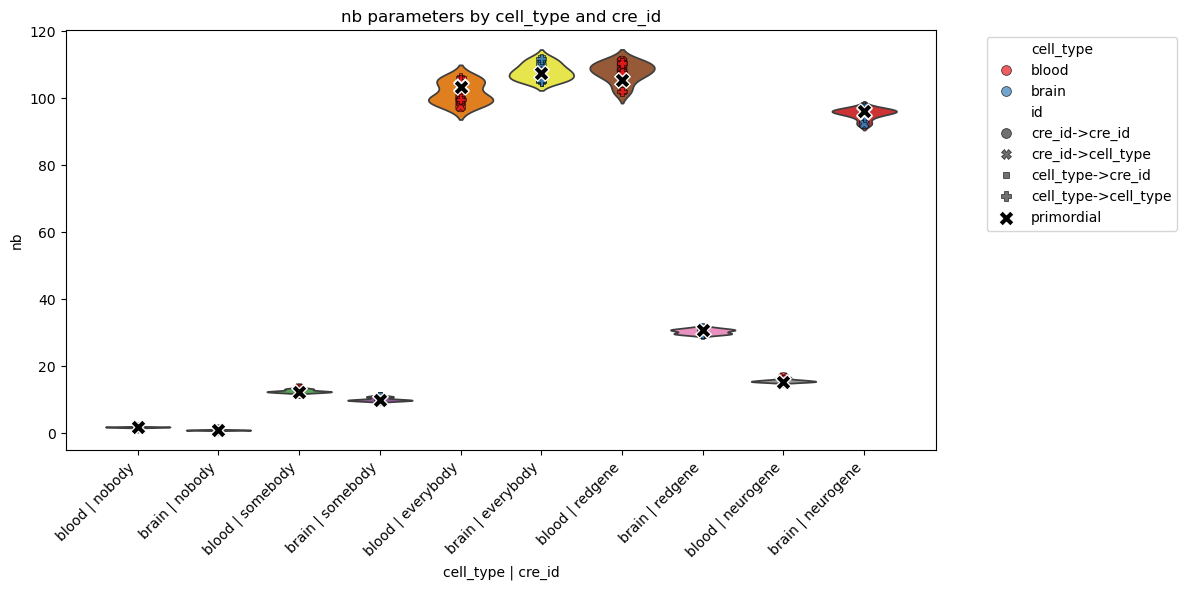

In [28]:
batch.plot_nb_spread()

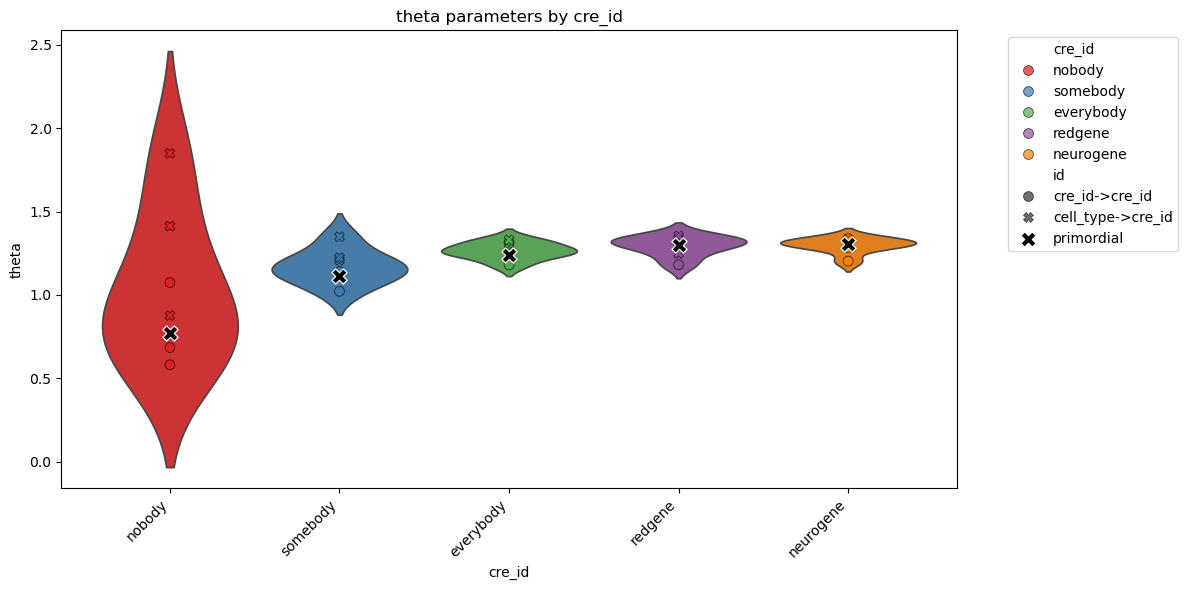

In [19]:
batch.plot_theta_spread("cre_id")

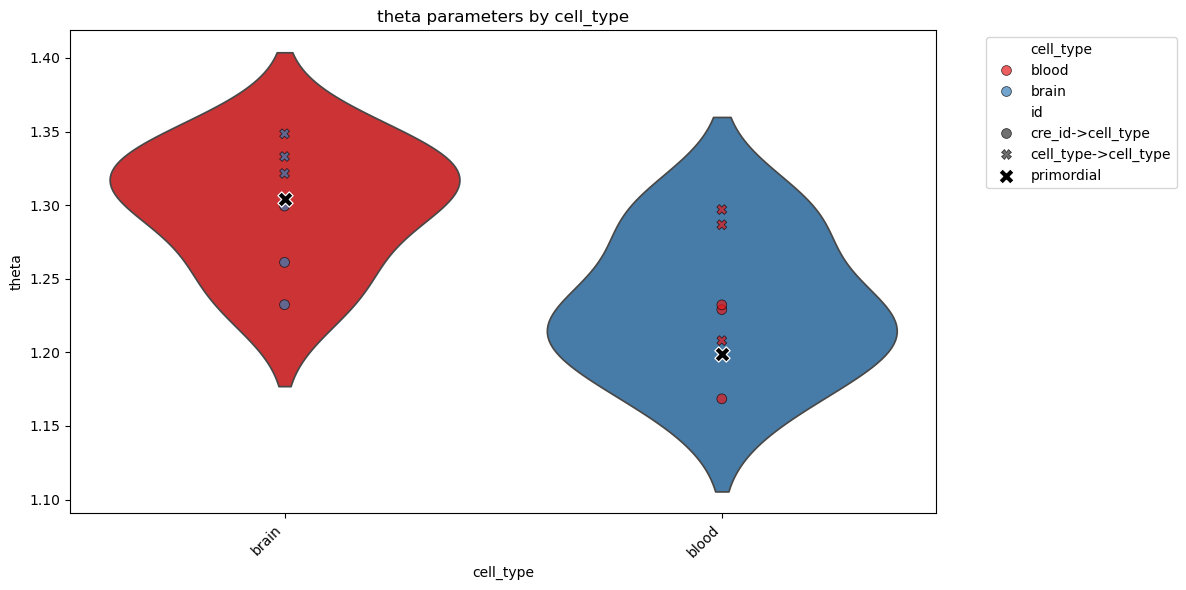

In [20]:
batch.plot_theta_spread("cell_type")

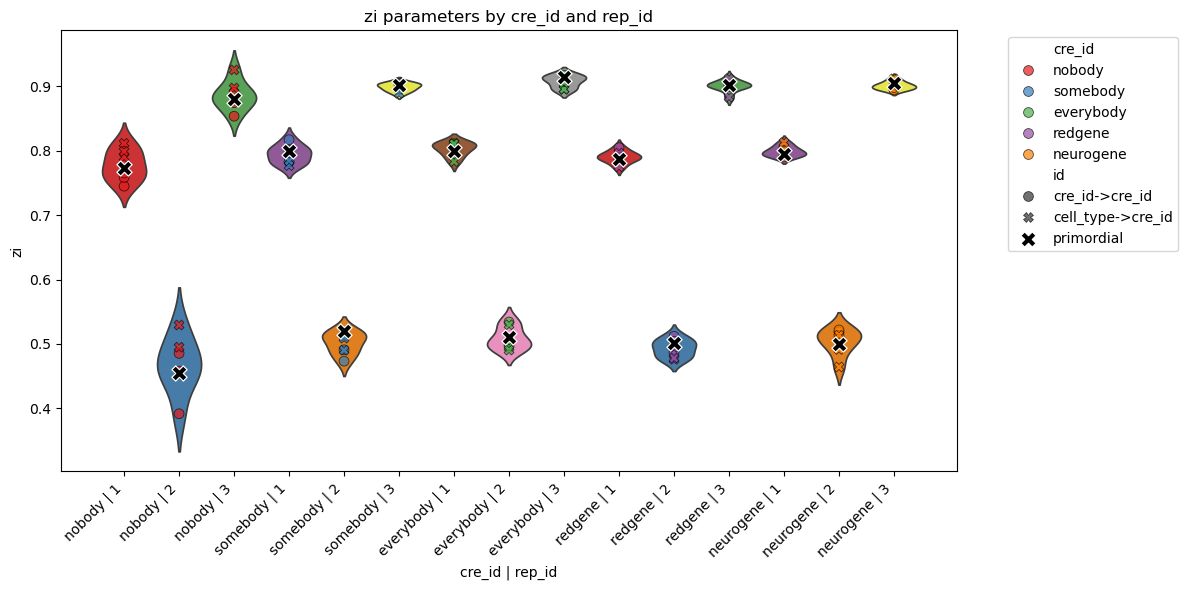

In [21]:
batch.plot_zi_spread("cre_id")

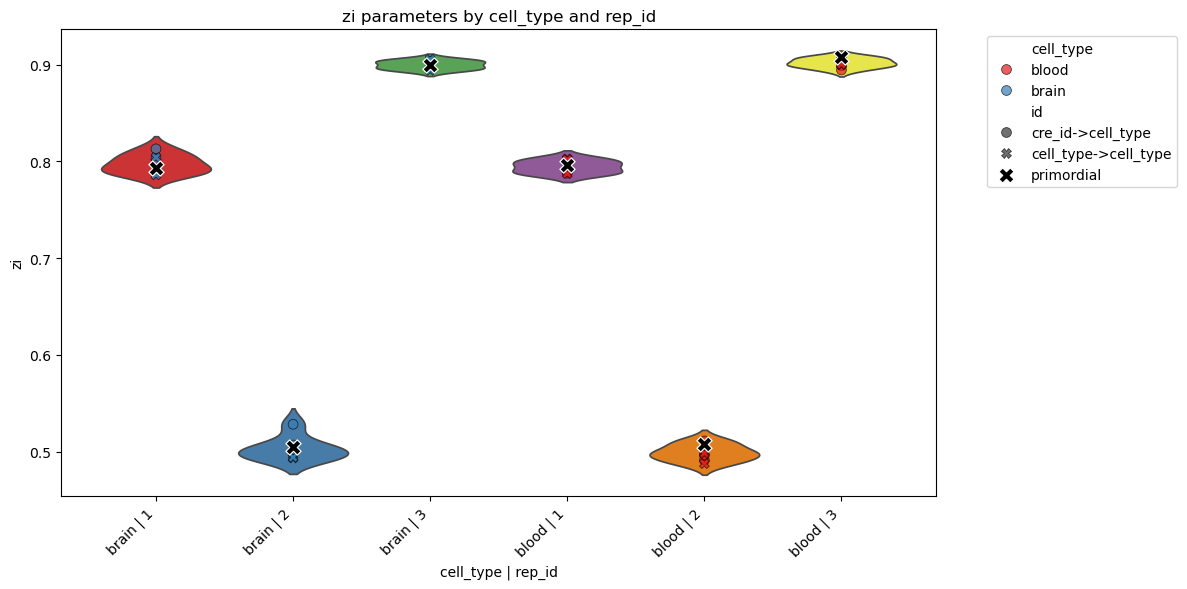

In [22]:
batch.plot_zi_spread("cell_type")

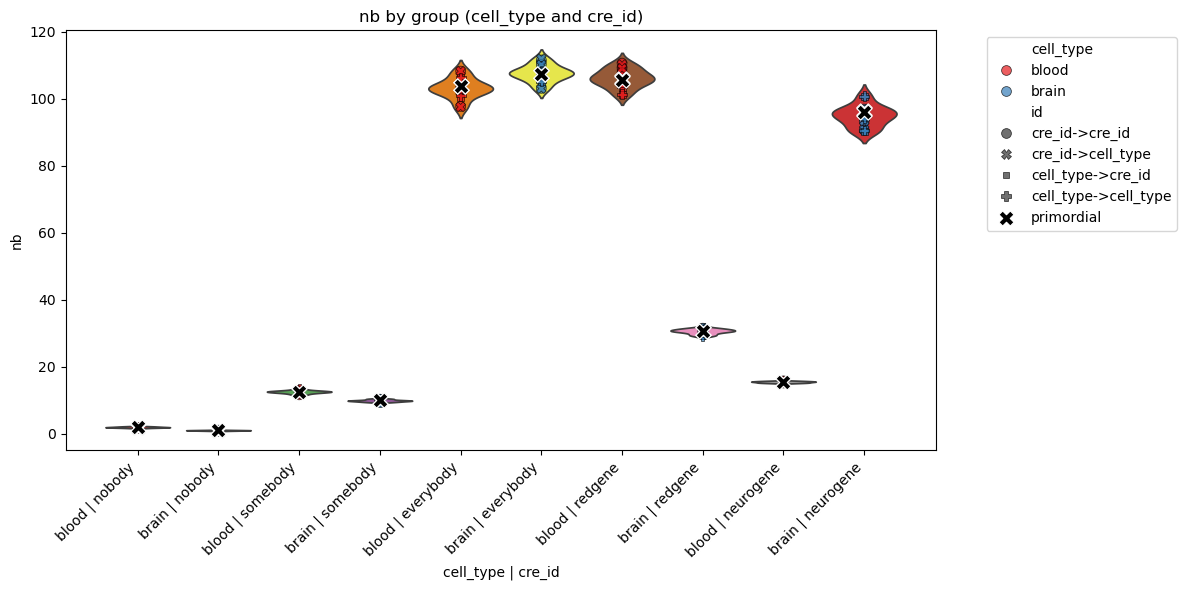

In [135]:
cluster.close()